In [1]:
import cv2
from pathlib import Path
import os

In [2]:
def video_info(path: str) -> dict:
    cap = cv2.VideoCapture(path)
    info = {
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "fps": int(cap.get(cv2.CAP_PROP_FPS)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()
    return info


input_info = video_info('data/input.mp4')
output_info = video_info('data/output.mp4')
print(input_info)
print(output_info)

n_frames = input_info['frame_count']
fps = input_info['fps']
width = input_info['width']
height = input_info['height']


{'frame_count': 301, 'fps': 30, 'width': 1920, 'height': 1080}
{'frame_count': 301, 'fps': 30, 'width': 1920, 'height': 1080}


## Разбиение видео на кадры

In [3]:
def decode_video(video_path: str, out_dir: str) -> list:
    # Создаем директорию для кадров
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    paths = []

    for i in range(n_frames):
        ok, frame = cap.read()
        path = os.path.join(out_dir, f"frame_{i:03d}.jpg")
        cv2.imwrite(path, frame)
        paths.append(path)

    cap.release()
    return paths


# Разбиваем оба видео на кадры
input_frame_paths = decode_video('data/input.mp4', './frames/input')
output_frame_paths = decode_video('data/output.mp4', './frames/output')

print("Извлечено кадров из input:", len(input_frame_paths))
print("Извлечено кадров из output:", len(output_frame_paths))

Извлечено кадров из input: 301
Извлечено кадров из output: 301


## Прасим xml файл

In [4]:
import xml.etree.ElementTree as ET


def get_xml_frame_range(xml_path: str) -> tuple:
    root = ET.parse(xml_path).getroot()
    frame_ids = [int(box.attrib['frame']) for box in root.findall('.//track/box')]
    return min(frame_ids), max(frame_ids)


xml_range = get_xml_frame_range('data/annotations.xml')
print(f'Диапазон кадров в XML: {xml_range[1]}')
print(f'В видео кадров: {n_frames}')


Диапазон кадров в XML: 900
В видео всего кадров: 301


In [17]:
def clip_box(raw_box: tuple, image_width: int, image_height: int):
    x1, y1, x2, y2 = raw_box
    x1 = max(0, min(int(round(x1)), image_width - 1))
    y1 = max(0, min(int(round(y1)), image_height - 1))
    x2 = max(0, min(int(round(x2)), image_width))
    y2 = max(0, min(int(round(y2)), image_height))

    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2, y2]


def load_cvat_tracks(xml_path: str, total_frames: int, image_width: int, image_height: int):
    root = ET.parse(xml_path).getroot()
    valid_frame_ids = set(range(total_frames))

    labels = [node.findtext('name') for node in root.findall('.//meta/task/labels/label')]
    objects_by_frame = {frame_idx: [] for frame_idx in range(total_frames)}
    skipped_boxes = 0

    for track_node in root.findall('track'):
        track_id = int(track_node.get('id', -1))
        label = track_node.get('label', 'unknown')

        for box_node in track_node.findall('box'):
            if box_node.get('outside') == '1':
                continue

            frame_idx = int(box_node.get('frame', -1))
            if frame_idx not in valid_frame_ids:
                skipped_boxes += 1
                continue

            raw_box = (float(box_node.attrib['xtl']), float(box_node.attrib['ytl']), float(box_node.attrib['xbr']),
                       float(box_node.attrib['ybr']),
                       )
            bbox = clip_box(raw_box, image_width, image_height)
            if bbox is None:
                skipped_boxes += 1
                continue
            objects_by_frame[frame_idx].append({'bbox_xyxy': bbox, 'label': label, 'track_id': track_id, })
    summary = {
        'labels': labels,
        'boxes': sum(len(items) for items in objects_by_frame.values()),
        'skipped': skipped_boxes,
        'annotated_frames': sum(bool(items) for items in objects_by_frame.values()),
    }
    return objects_by_frame, summary


frames, ano_info = load_cvat_tracks('data/annotations.xml', n_frames, width, height)

xml_boxes = ano_info['boxes'] + ano_info['skipped']
print(f'Всего bbox в XML: {xml_boxes}')
print(f'Валидных bbox: {ano_info["boxes"]}')
print(f'Отброшено: {ano_info["skipped"]}')
print(f'Размеченных кадров: {ano_info["annotated_frames"]} из {n_frames}')
print(f'Классы: {ano_info["labels"]}')

Всего bbox в XML: 9659
Валидных bbox: 3647
Отброшено: 6012
Размеченных кадров: 301 из 301
Классы: ['car', 'minivan']


Кадр 100:
  Маска разницы: (1080, 1920), белых пиксел: 16138


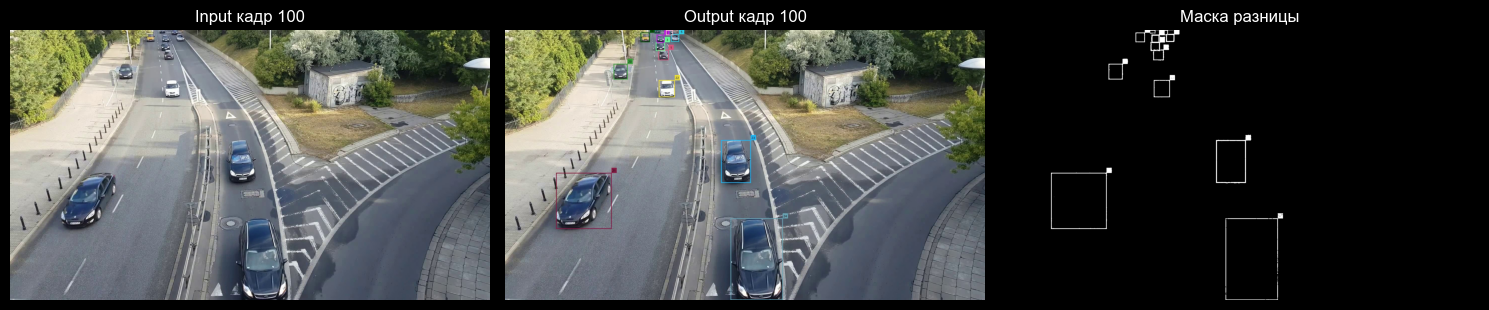

In [18]:
# Читаем пару кадров
def get_frame_pair(frame_id: int):
    input_frame = cv2.imread(f'./frames/input/frame_{frame_id:03d}.jpg')
    output_frame = cv2.imread(f'./frames/output/frame_{frame_id:03d}.jpg')
    return input_frame, output_frame

# Вычисляем разницу
def compute_difference(frame_clean, frame_marked, threshold=20):
    diff = cv2.absdiff(frame_clean, frame_marked)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return mask

# Тестируем на одном кадре
sample_id = 100
clean, marked = get_frame_pair(sample_id)
mask = compute_difference(clean, marked, threshold=20)

print(f'Кадр {sample_id}:')
print(f'  Маска разницы: {mask.shape}, белых пикселей: {(mask > 0).sum()}')

# Визуализация
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv2.cvtColor(clean, cv2.COLOR_BGR2RGB))
ax[0].set_title(f'Input кадр {sample_id}')
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
ax[1].set_title(f'Output кадр {sample_id}')
ax[1].axis('off')

ax[2].imshow(mask, cmap='gray')
ax[2].set_title('Маска разницы')
ax[2].axis('off')

plt.tight_layout()

## Извлечение контуров


Найдено контуров: 20
Валидных bounding box: 9
Первые 3 bbox:
  Box 0: (902, 998) -> (1112, 1080), размер: 210x82
  Box 1: (902, 753) -> (1074, 1052), размер: 172x299
  Box 2: (1091, 733) -> (1132, 913), размер: 41x180


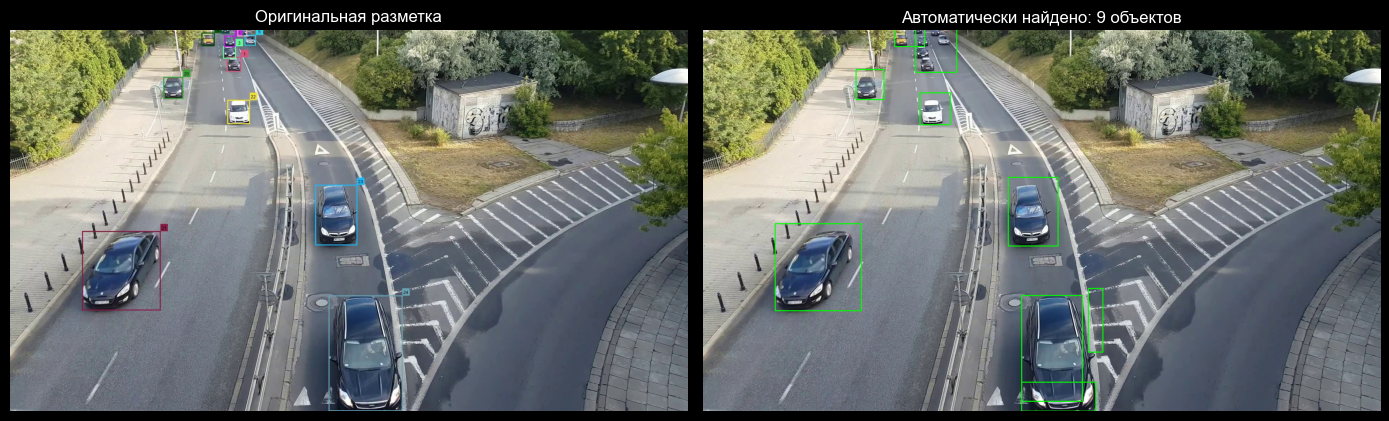

In [19]:
def find_contours_from_mask(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contours

# Преобразуем контуры в bbox
def extract_bboxes_from_contours(contours):
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        # Фильтруем по размеру
        if 100 < w * h < 100000 and w > 10 and h > 10:
            boxes.append([float(x), float(y), float(x + w), float(y + h)])
    return boxes

# Тестируем на том же кадре
contours = find_contours_from_mask(mask)
detected_boxes = extract_bboxes_from_contours(contours)

print(f'Найдено контуров: {len(contours)}')
print(f'Валидных bounding box: {len(detected_boxes)}')
print(f'Первые 3 bbox:')
for i, box in enumerate(detected_boxes[:3]):
    x1, y1, x2, y2 = box
    print(f'  Box {i}: ({int(x1)}, {int(y1)}) -> ({int(x2)}, {int(y2)}), размер: {int(x2-x1)}x{int(y2-y1)}')

# Рисуем результат
def draw_boxes_on_image(image, boxes, color=(0, 255, 0)):
    vis = image.copy()
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
    return vis

result = draw_boxes_on_image(clean, detected_boxes)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
ax[0].set_title('Оригинальная разметка')
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
ax[1].set_title(f'Автоматически найдено: {len(detected_boxes)} объектов')
ax[1].axis('off')

plt.tight_layout()

## Вычисление IoU

In [21]:
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = box1_area + box2_area - intersection

    return intersection / union


# Сравниваем найденные bbox с XML-разметкой на одном кадре
frame_id = 100
xml_boxes = [item['bbox_xyxy'] for item in frames[frame_id]]
cv_boxes = detected_boxes

tp = 0
fp = 0
used_xml = []
iou_values = []

print(f'Кадр {frame_id}')
print(f'Bbox из XML: {len(xml_boxes)}')
print(f'Bbox найдено OpenCV: {len(cv_boxes)}')
print()

for cv_num, cv_box in enumerate(cv_boxes):
    best_iou = 0
    best_xml_num = -1

    for xml_num, xml_box in enumerate(xml_boxes):
        if xml_num in used_xml:
            continue

        iou = calculate_iou(cv_box, xml_box)
        if iou > best_iou:
            best_iou = iou
            best_xml_num = xml_num

    iou_values.append(best_iou)

    if best_iou >= 0.5:
        tp += 1
        used_xml.append(best_xml_num)
        status = 'верно найден'
    else:
        fp += 1
        status = 'лишний bbox'

    print(f'OpenCV bbox {cv_num}: лучший XML bbox {best_xml_num}, IoU = {best_iou:.3f}, {status}')

fn = len(xml_boxes) - tp
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
mean_iou = sum(iou_values) / len(iou_values)

print()
print('Итог')
print(f'TP верно найдено: {tp}')
print(f'FP лишние bbox: {fp}')
print(f'FN пропущено объектов: {fn}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1-score: {f1:.3f}')
print(f'Mean IoU: {mean_iou:.3f}')


Кадр 100
Bbox из XML: 12
Bbox найдено OpenCV: 9

OpenCV bbox 0: лучший XML bbox 11, IoU = 0.251, лишний bbox
OpenCV bbox 1: лучший XML bbox 11, IoU = 0.746, верно найден
OpenCV bbox 2: лучший XML bbox -1, IoU = 0.000, лишний bbox
OpenCV bbox 3: лучший XML bbox 8, IoU = 0.828, верно найден
OpenCV bbox 4: лучший XML bbox 10, IoU = 0.738, верно найден
OpenCV bbox 5: лучший XML bbox 9, IoU = 0.562, верно найден
OpenCV bbox 6: лучший XML bbox 7, IoU = 0.517, верно найден
OpenCV bbox 7: лучший XML bbox 0, IoU = 0.119, лишний bbox
OpenCV bbox 8: лучший XML bbox 4, IoU = 0.338, лишний bbox

Итог
TP верно найдено: 5
FP лишние bbox: 4
FN пропущено объектов: 7
Precision: 0.556
Recall: 0.417
F1-score: 0.476
Mean IoU: 0.455


## Сравнение методов извлечения

In [22]:
import pandas as pd
import numpy as np

# Методы извлечения
def extract_diff_contours(input_frame, output_frame, threshold=20):
    diff = cv2.absdiff(input_frame, output_frame)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return extract_bboxes_from_contours(find_contours_from_mask(mask))

def extract_canny_edges(input_frame, output_frame, threshold=20):
    diff = cv2.absdiff(input_frame, output_frame)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    edges = cv2.Canny(mask, 50, 150)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)
    return extract_bboxes_from_contours(find_contours_from_mask(edges))

def extract_hsv_color(input_frame, output_frame):
    hsv = cv2.cvtColor(output_frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (0, 50, 50), (179, 255, 255))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return extract_bboxes_from_contours(find_contours_from_mask(mask))

def match_detections(pred_boxes, gt_boxes, iou_threshold=0.5):
    tp = 0
    fp = 0
    used_gt = []
    ious = []

    for pred_box in pred_boxes:
        best_iou = 0
        best_gt_num = -1

        for gt_num, gt_box in enumerate(gt_boxes):
            if gt_num in used_gt:
                continue

            iou = calculate_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_num = gt_num

        ious.append(best_iou)

        if best_iou >= iou_threshold:
            tp += 1
            used_gt.append(best_gt_num)
        else:
            fp += 1

    fn = len(gt_boxes) - tp
    return tp, fp, fn, ious


def evaluate_method(method_name, method_fn, n_eval=50):
    tp_total, fp_total, fn_total = 0, 0, 0
    ious_total = []
    for frame_id in range(0, n_eval):
        clean, marked = get_frame_pair(frame_id)
        pred = method_fn(clean, marked)
        gt = [item['bbox_xyxy'] for item in frames[frame_id]]
        tp, fp, fn, ious = match_detections(pred, gt)
        tp_total += tp
        fp_total += fp
        fn_total += fn
        ious_total.extend(ious)
    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    mean_iou = np.mean(ious_total) if ious_total else 0
    return {'method': method_name, 'precision': precision, 'recall': recall, 'f1': f1, 'mean_iou': mean_iou, 'tp': tp_total, 'fp': fp_total}

methods = {'diff_th10': lambda i, o: extract_diff_contours(i, o, threshold=10), 'diff_th15': lambda i, o: extract_diff_contours(i, o, threshold=15), 'diff_th20': lambda i, o: extract_diff_contours(i, o, threshold=20), 'canny_th15': lambda i, o: extract_canny_edges(i, o, threshold=15), 'hsv_color': lambda i, o: extract_hsv_color(i, o)}
results = [evaluate_method(name, fn) for name, fn in methods.items()]
df_methods = pd.DataFrame(results).sort_values('f1', ascending=False)
print('Сравнение методов:')
print(df_methods[['method', 'precision', 'recall', 'f1', 'mean_iou']].to_string(index=False))
best_method = df_methods.iloc[0]['method']
best_method_fn = methods[best_method]
print(f'\nЛучший метод: {best_method} (F1 = {df_methods.iloc[0]["f1"]:.3f})')

Сравнение методов:
    method  precision   recall       f1  mean_iou
 diff_th20   0.682759 0.700472 0.691502  0.525511
 diff_th15   0.677419 0.693396 0.685315  0.529375
 diff_th10   0.653488 0.662736 0.658080  0.536388
canny_th15   0.636161 0.672170 0.653670  0.514330
 hsv_color   0.086602 0.525943 0.148716  0.072180

Лучший метод: diff_th20 (F1 = 0.692)


## Предсказания для всего датасета

In [23]:
best_predictions = []
for frame_id in range(n_frames):
    clean, marked = get_frame_pair(frame_id)
    pred = best_method_fn(clean, marked)
    best_predictions.append(pred)
    if (frame_id + 1) % 50 == 0:
        print(f'Обработано {frame_id + 1}/{n_frames}')
print(f'Всего объектов: {sum(len(p) for p in best_predictions)}')

Обработано 50/301
Обработано 100/301
Обработано 150/301
Обработано 200/301
Обработано 250/301
Обработано 300/301
Всего объектов: 2989


## COCO датасет

In [24]:
import json


def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]

def build_coco_dataset(predictions):
    coco = {'info': {}, 'licenses': [], 'categories': [{'id': 1, 'name': 'car', 'supercategory': 'vehicle'}], 'images': [], 'annotations': []}
    ann_id = 1
    for frame_id in range(n_frames):
        coco['images'].append({'id': frame_id + 1, 'file_name': f'frame_{frame_id:03d}.jpg', 'width': width, 'height': height, 'frame_id': frame_id})
        for box in predictions[frame_id]:
            x, y, w, h = xyxy_to_xywh(box)
            coco['annotations'].append({'id': ann_id, 'image_id': frame_id + 1, 'category_id': 1, 'bbox': [x, y, w, h], 'area': float(w * h), 'iscrowd': 0, 'segmentation': []})
            ann_id += 1
    return coco

coco_data = build_coco_dataset(best_predictions)
Path('annotations').mkdir(exist_ok=True)
with open('annotations/coco.json', 'w') as f:
    json.dump(coco_data, f)
print(f'Создано: {len(coco_data["images"])} изображений, {len(coco_data["annotations"])} аннотаций')

Создано: 301 изображений, 2989 аннотаций


## Разделение train/val/test

In [25]:
def split_coco(coco, train_ratio=0.70, val_ratio=0.15):
    train_end = int(len(coco['images']) * train_ratio)
    val_end = int(len(coco['images']) * (train_ratio + val_ratio))
    train_ids = {img['id'] for img in coco['images'] if img['frame_id'] < train_end}
    val_ids = {img['id'] for img in coco['images'] if train_end <= img['frame_id'] < val_end}
    test_ids = {img['id'] for img in coco['images'] if img['frame_id'] >= val_end}
    def subset(image_ids):
        return {'info': coco['info'], 'licenses': coco['licenses'], 'categories': coco['categories'], 'images': [img for img in coco['images'] if img['id'] in image_ids], 'annotations': [ann for ann in coco['annotations'] if ann['image_id'] in image_ids]}
    return subset(train_ids), subset(val_ids), subset(test_ids)

train_coco, val_coco, test_coco = split_coco(coco_data)
splits = [('train', train_coco), ('val', val_coco), ('test', test_coco)]
for split_name, split_data in splits:
    with open(f'annotations/{split_name}.coco.json', 'w') as f:
        json.dump(split_data, f)
    print(f'{split_name}: {len(split_data["images"])} изображений, {len(split_data["annotations"])} аннотаций')

train: 210 изображений, 1803 аннотаций
val: 45 изображений, 556 аннотаций
test: 46 изображений, 630 аннотаций


## Установка зависимостей

In [26]:
!pip install torch torchvision torchmetrics pycocotools -q

## PyTorch Dataset и DataLoader

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader

class CocoFramesDataset(Dataset):
    def __init__(self, img_dir, ann_path, max_side=640):
        self.img_dir = Path(img_dir)
        self.max_side = max_side
        with open(ann_path) as f:
            self.coco = json.load(f)
        self.images = sorted(self.coco['images'], key=lambda x: x['id'])
        self.anns_by_image = {img['id']: [] for img in self.images}
        for ann in self.coco['annotations']:
            self.anns_by_image[ann['image_id']].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        image = cv2.imread(str(self.img_dir / img_info['file_name']))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        boxes = []
        for ann in self.anns_by_image[img_info['id']]:
            x, y, w, h = ann['bbox']
            if w > 1 and h > 1:
                boxes.append([x, y, x + w, y + h])
        boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.ones((len(boxes),), dtype=torch.int64)
        h, w = image.shape[:2]
        scale = min(self.max_side / max(h, w), 1.0)
        if scale < 1.0:
            image = cv2.resize(image, (int(w * scale), int(h * scale)))
            boxes *= scale
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        target = {'boxes': boxes, 'labels': labels, 'image_id': torch.tensor([img_info['id']]), 'area': area, 'iscrowd': torch.zeros((len(boxes),), dtype=torch.int64)}
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = CocoFramesDataset('frames/input', 'annotations/train.coco.json')
val_dataset = CocoFramesDataset('frames/input', 'annotations/val.coco.json')
test_dataset = CocoFramesDataset('frames/input', 'annotations/test.coco.json')

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

print(f'train/val/test: {len(train_dataset)}, {len(val_dataset)}, {len(test_dataset)}')

train/val/test: 210, 45, 46


## Обучение модели

In [29]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights=None, weights_backbone=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    losses = []
    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate_map(model, loader, device):
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    for images, targets in loader:
        images = [img.to(device) for img in images]
        preds = model(images)
        preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets = [{k: v.cpu() for k, v in t.items()} for t in targets]
        metric.update(preds, targets)
    return metric.compute()

num_classes = 2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

model = get_model(num_classes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

history = {'train_loss': [], 'val_map': [], 'val_map50': []}
best_map = -1.0

for epoch in range(6):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_result = evaluate_map(model, val_loader, device)
    val_map = val_result['map'].item()
    val_map50 = val_result['map_50'].item()
    history['train_loss'].append(train_loss)
    history['val_map'].append(val_map)
    history['val_map50'].append(val_map50)
    print(f'Epoch {epoch + 1}/6: loss={train_loss:.4f}, val_mAP={val_map:.4f}, val_mAP50={val_map50:.4f}')
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), 'best_detector.pth')

model.load_state_dict(torch.load('best_detector.pth', map_location=device))

device: cpu
Epoch 1/6: loss=0.6157, val_mAP=0.0200, val_mAP50=0.0869
Epoch 2/6: loss=0.4904, val_mAP=0.0430, val_mAP50=0.1469
Epoch 3/6: loss=0.5481, val_mAP=0.0773, val_mAP50=0.2164
Epoch 4/6: loss=0.5963, val_mAP=0.0724, val_mAP50=0.2066
Epoch 5/6: loss=0.6394, val_mAP=0.0858, val_mAP50=0.2201
Epoch 6/6: loss=0.6676, val_mAP=0.0993, val_mAP50=0.2710


<All keys matched successfully>

## Финальные результаты

Финальные метрики:
split    mAP  mAP50  mAP75  mAR100
train 0.4379 0.8016 0.4436  0.5179
  val 0.0993 0.2710 0.0559  0.1624
 test 0.0738 0.1837 0.0506  0.1259


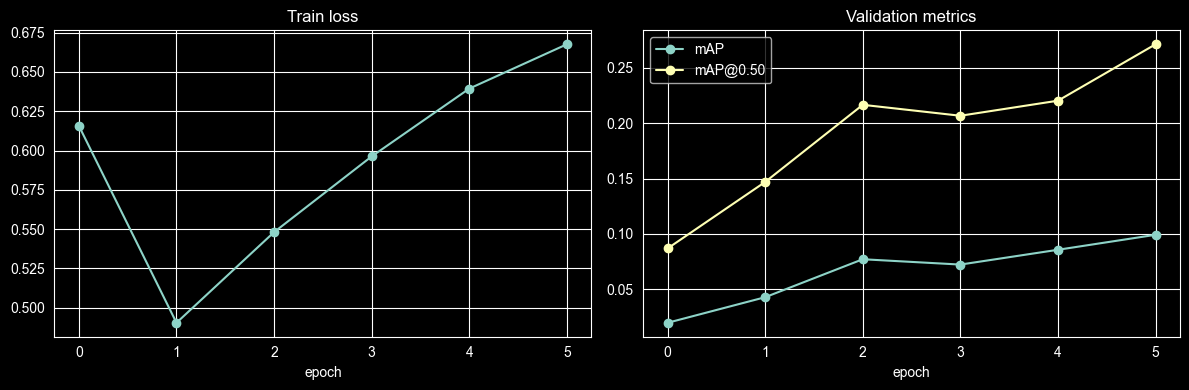

In [30]:
train_result = evaluate_map(model, train_loader, device)
val_result = evaluate_map(model, val_loader, device)
test_result = evaluate_map(model, test_loader, device)

def map_to_row(split_name, result):
    return {'split': split_name, 'mAP': result['map'].item(), 'mAP50': result['map_50'].item(), 'mAP75': result['map_75'].item(), 'mAR100': result['mar_100'].item()}

map_df = pd.DataFrame([map_to_row('train', train_result), map_to_row('val', val_result), map_to_row('test', test_result)]).round(4)
print('Финальные метрики:')
print(map_df.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train_loss'], marker='o')
ax[0].set_title('Train loss')
ax[0].set_xlabel('epoch')
ax[0].grid(True)
ax[1].plot(history['val_map'], marker='o', label='mAP')
ax[1].plot(history['val_map50'], marker='o', label='mAP@0.50')
ax[1].set_title('Validation metrics')
ax[1].set_xlabel('epoch')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()

## Визуализация предсказаний

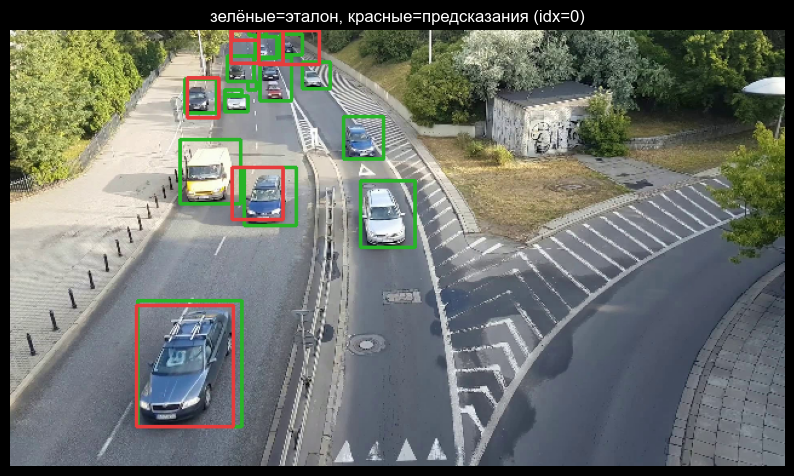

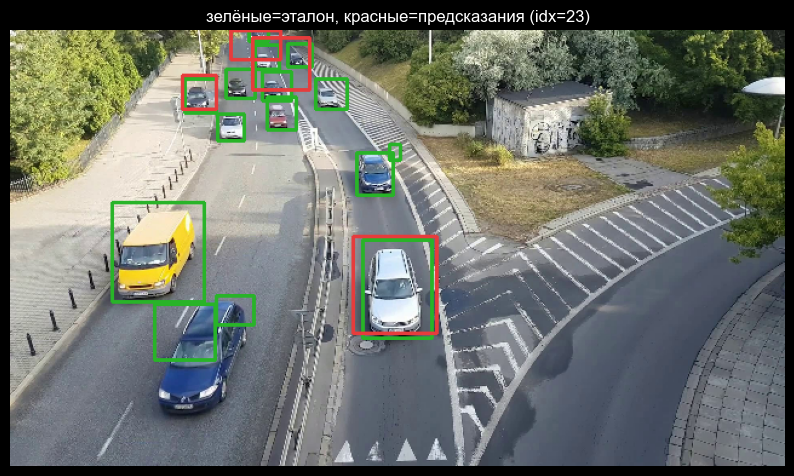

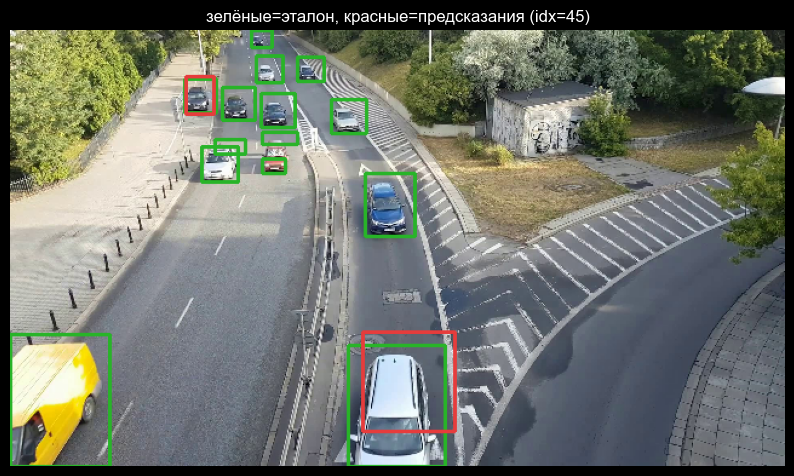

In [31]:
@torch.no_grad()
def predict_item(dataset, idx, score_threshold=0.5):
    image, target = dataset[idx]
    pred = model([image.to(device)])[0]
    keep = pred['scores'].cpu() >= score_threshold
    pred_boxes = pred['boxes'].cpu()[keep].tolist()
    pred_scores = pred['scores'].cpu()[keep].tolist()
    return image, target, pred_boxes, pred_scores

def show_prediction(dataset, idx):
    image, target, pred_boxes, pred_scores = predict_item(dataset, idx)
    canvas = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8).copy()
    for box in target['boxes'].tolist():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (40, 180, 40), 2)
    for box, score in zip(pred_boxes, pred_scores):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (230, 60, 60), 2)
    plt.figure(figsize=(10, 6))
    plt.imshow(canvas)
    plt.title(f'зелёные=эталон, красные=предсказания (idx={idx})')
    plt.axis('off')

for idx in [0, len(test_dataset) // 2, len(test_dataset) - 1]:
    show_prediction(test_dataset, idx)

## Вывод

В результате была обучена модель Faster R-CNN MobileNetV3 для детекции автомобилей на кадрах видео. Качество оценивалось на train, validation и test выборках с помощью метрик mAP, mAP50, mAP75 и mAR100. Значения на validation и test ниже, чем на train, что показывает ограниченное качество обобщения модели. Это связано с тем, что обучение проводилось не на ручной разметке, а на bbox, автоматически извлечённых из видео через OpenCV, где часть объектов была пропущена или найдена неточно